<a href="https://colab.research.google.com/github/Merhawi12/BookStore/blob/main/emailfilter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [6]:
data = pd.read_csv("spam_ham_dataset.csv")

In [11]:
data.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


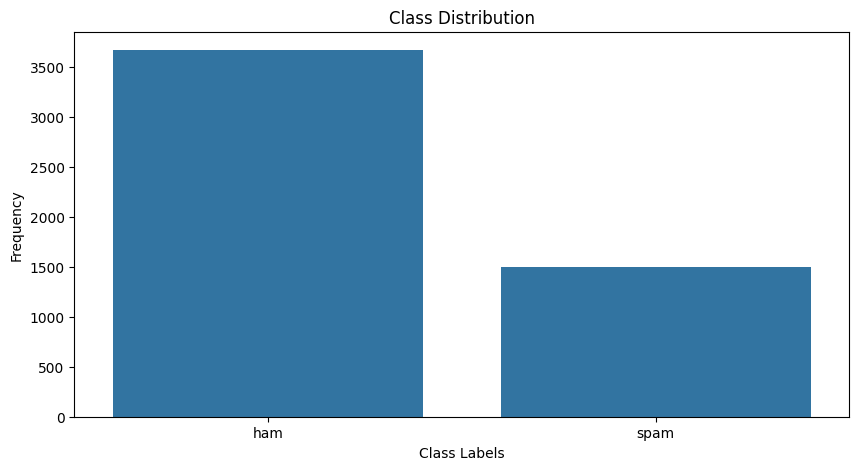

In [44]:
# Class Balance Analysis
class_counts = data['label'].value_counts()

# Plot the class distribution
plt.figure(figsize=(10, 5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Class Distribution')
plt.ylabel('Frequency')
plt.xlabel('Class Labels')
plt.show()

In [17]:
from collections import Counter

In [28]:
data[data['label'] == "ham"]["text"]

,text
0,Subject: enron methanol ; meter # : 988291\r\n...
1,"Subject: hpl nom for january 9 , 2001\r\n( see..."
2,"Subject: neon retreat\r\nho ho ho , we ' re ar..."
4,Subject: re : indian springs\r\nthis deal is t...
5,Subject: ehronline web address change\r\nthis ...
...,...
5165,"Subject: fw : crosstex energy , driscoll ranch..."
5166,Subject: put the 10 on the ft\r\nthe transport...
5167,Subject: 3 / 4 / 2000 and following noms\r\nhp...
5168,Subject: calpine daily gas nomination\r\n>\r\n...


In [30]:
def get_most_common_word(class_label, num_words, column_name, dataset):
  text = "".join(message for message in dataset[dataset['label'] == class_label][column_name])

  words = text.lower().split()

  return Counter(words).most_common()

In [34]:
get_most_common_word("spam", 20, "text", data)

[('.', 19399),
 (',', 11227),
 ('-', 7934),
 ('the', 7254),
 ('/', 5707),
 ('to', 5160),
 ('and', 4903),
 (':', 4612),
 ('of', 4490),
 ('a', 3787),
 ('in', 3129),
 ('=', 3089),
 ('you', 2794),
 ('for', 2523),
 ('!', 2448),
 ('this', 2283),
 ('is', 2256),
 ('your', 1946),
 ('?', 1927),
 ("'", 1762),
 ('$', 1666),
 (')', 1548),
 ('(', 1513),
 ('with', 1470),
 ('that', 1348),
 ('s', 1315),
 ('|', 1309),
 ('be', 1303),
 ('or', 1300),
 ('on', 1259),
 ('3', 1237),
 ('_', 1218),
 ('Subject:', 1209),
 ('as', 1199),
 ('are', 1166),
 ('i', 1138),
 ('we', 1137),
 ('%', 1105),
 ('it', 1087),
 ('not', 1042),
 ('our', 1035),
 (';', 993),
 ('com', 991),
 ('http', 983),
 ('from', 981),
 ('*', 924),
 ('have', 887),
 ('all', 883),
 ('2', 849),
 ('no', 756),
 ('at', 743),
 ('company', 728),
 ('1', 718),
 ('0', 698),
 ('will', 691),
 ('by', 668),
 ('e', 631),
 ('can', 613),
 ('an', 607),
 ('more', 599),
 ('www', 587),
 ('here', 586),
 ('00', 585),
 ('@', 567),
 ('any', 551),
 ('if', 549),
 ('information',

# Text Length Analysis

In [36]:
len("This is a sapm email")

20

In [46]:
data['text_length'] = data['text'].apply(len)

In [48]:
data.groupby("label")['text_length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,3672.0,977.008170,1382.827493,18.0,231.75,530.0,1227.25,32258.0
spam,1499.0,1223.256171,1825.986210,11.0,283.00,576.0,1253.50,22073.0


In [49]:
data.head()

,Unnamed: 0,label,text,label_num,text_length
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0,327
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0,97
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0,2524
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1,414
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0,336


# **Cleaning punctution and most common words**

In [59]:
import string
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [61]:
ENGLISH_STOP_WORDS

frozenset({'a',
           'about',
           'above',
           'across',
           'after',
           'afterwards',
           'again',
           'against',
           'all',
           'almost',
           'alone',
           'along',
           'already',
           'also',
           'although',
           'always',
           'am',
           'among',
           'amongst',
           'amoungst',
           'amount',
           'an',
           'and',
           'another',
           'any',
           'anyhow',
           'anyone',
           'anything',
           'anyway',
           'anywhere',
           'are',
           'around',
           'as',
           'at',
           'back',
           'be',
           'became',
           'because',
           'become',
           'becomes',
           'becoming',
           'been',
           'before',
           'beforehand',
           'behind',
           'being',
           'below',
           'beside',
           'besides'

In [62]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [66]:
def preprocess_text(text):

  text = text.lower()

  text = text.translate(str.maketrans("", "", string.punctuation))

  words = text.split()

  words = [word for word in words if word not in ENGLISH_STOP_WORDS]

  text = ''.join(words)

  return text

In [81]:
data['text'].values[0]

"Subject: enron methanol ; meter # : 988291\r\nthis is a follow up to the note i gave you on monday , 4 / 3 / 00 { preliminary\r\nflow data provided by daren } .\r\nplease override pop ' s daily volume { presently zero } to reflect daily\r\nactivity you can obtain from gas control .\r\nthis change is needed asap for economics purposes ."

In [73]:
preprocess_text(data['text'].values[0])

'subjectenronmethanolmeter988291follownotegavemonday4300preliminaryflowdataprovideddarenoverridepopsdailyvolumepresentlyzeroreflectdailyactivityobtaingascontrolchangeneededasapeconomicspurposes'

In [77]:
data['cleaned_text'] = data['text'].apply(preprocess_text)

In [82]:
ham_words = get_most_common_word('ham', 20, 'cleaned_text', data)
spam_words = get_most_common_word('spam', 20, 'cleaned_text', data)

In [85]:
ham_words

[('...\x01sbusinessgoalspleasedsharedcompany\x01sfinancialsuccessenronstockoptionsknowcurrentemployeestockoptionprogramknownemployeestockoptionprogramaesopbegan1994providedvalueparticipants2000employeesparticipatedprograminceptionrealized1119increasevaluestockoptionsassumingstockprice70lifeprogramenronstockoptionsvaluabletotalcompensationpackagecontributingfactorperformanceenron\x01scontinuedsuccessenronexecutivecommitteecompensationmanagementdevelopmentcommitteeenronboarddirectorsdecidedcontinueofferstockoptionscompensationpackage12000committeeapprovedemployeestockoptionprogramcalendaryears20012005enronoptions\x01stockoptionprogramexpectedenronoptions\x01stockoptionprogramgrantedeffectivedecember292000employeeseligibledatenotenewprogramsubjectfinalapprovalenron\x01sboarddirectorsfollowsenronoptions\x01stockoptionprogramstockoptionseligibletimetimeregularemployeesdomesticinternationalcompanieslocationsgrantnonqualifiedstockoptionsequal25annualbasesalary5annualbasesalaryyear5yearperiodd

In [86]:
data['cleaned_text']

,cleaned_text
0,subjectenronmethanolmeter988291follownotegavem...
1,subjecthplnomjanuary92001attachedfilehplnol09x...
2,subjectneonretreathohohowonderfultimeyearneonl...
3,subjectphotoshopwindowsofficecheapmaintrending...
4,subjectindianspringsdealbooktecopvrrevenueunde...
...,...
5166,subject10fttransportvolumesdecreased2500010000...
5167,subject342000followingnomshpltextra15mmcfdweek...
5168,subjectcalpinedailygasnominationjuliementionea...
5169,subjectindustrialworksheetsaugust2000activitya...


# **How to transform email data from text to numbers vectorization**